## Comparison of fixed loop and profiler

The data have been acquired by Pritam Yogeshwar (LIAG Institute for Applied Geophysics) on the LIAG testsite Schillerslage. The testsite has been extensively investigated by using ERT&SIP (Attwa & Günther 2013), GPR and MRT (Jiang et al. 2020) and laboratory measurements. See Dlugosch (2014) for an extensive description). It comprises ~23m thick glaciofluviatile sediments, two sandy aquifers separated by a till layer, above cretaceous shale.
The sandy layers are in a range of 200-300 Ohmm, but the till is about 40 Ohmm, whereas the shale is in the range of 10 Ohmm.
The Groundwater level is expected at about 2m depth.

The sTEM10 device was used with a 20x20m fixed loop and a central receiver, as well as the profiler compact using two separated 1.65m rectangular loops separated by 11.65m.

In [1]:
from pytem import TEM

### Fixed-loop data

We first import the fixed-loop data consisting of six soundings.

In [2]:
fix = TEM("20x20.xyz")
print(fix)

TEM profile with 6 soundings
50 times (1.245463e-05-0.02382765)


Inspection with `fix.showSounding(5)` shows that sounding 5 is of bad quality, so we remove it and show all soundings.

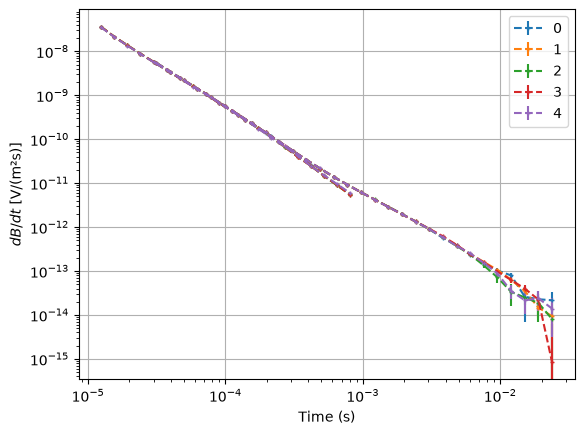

In [3]:
fix.filter(n=5)
ax = fix.showSoundings()
ax.legend();

All are on top of each other until 10ms. Note that the low moment (curves until 0.8ms) is separated from the high moment data from about 0.4ms on.
The apparent resistivity shows this deviation towards lower B-field derivatives more distinctly by improved values.

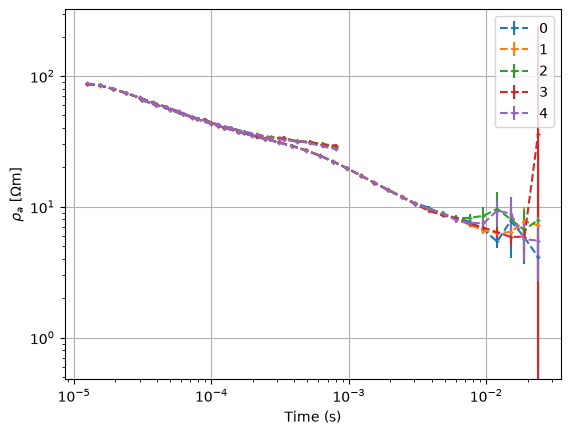

In [4]:
ax = fix.showSoundings(rhoa=True)
ax.legend();

As the errors increase for late times, we clip the data there.
We choose the sounding 2.

<Axes: xlabel='Time (s)', ylabel='$dB/dt$ [V/(m²s)]'>

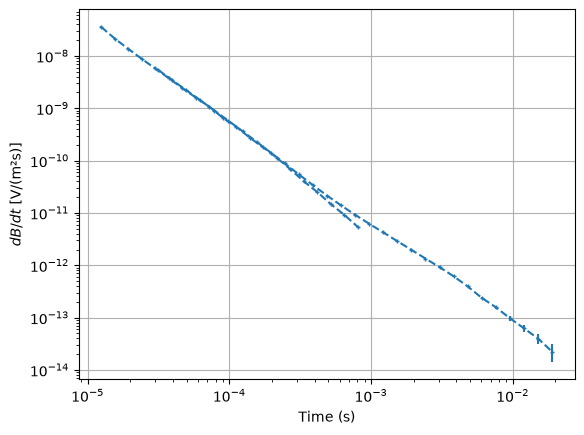

In [5]:
fix.filter(tmax=2e-2)
fix.showSounding(index=3)

For inversion, we choose a user-defined thickness vector and invert the sounding.

05/08/26 - 20:35:58 - pyGIMLi - INFO - Starting inversion.
05/08/26 - 20:35:58 - pyGIMLi - INFO - fop: <pytem.temmodelling.TEMRhoModelling object at 0x000001776617C630>
05/08/26 - 20:35:58 - pyGIMLi - INFO - Data transformation: Identity transform
05/08/26 - 20:35:58 - pyGIMLi - INFO - Model transformation: Logarithmic transform
05/08/26 - 20:35:58 - pyGIMLi - INFO - min/max (data): 2.2e-14/3.6e-08
05/08/26 - 20:35:58 - pyGIMLi - INFO - min/max (error): 3%/37.4%
05/08/26 - 20:35:58 - pyGIMLi - INFO - min/max (start model): 250/250


--------------------------------------------------------------------------------


05/08/26 - 20:36:29 - pyGIMLi - INFO - inv.iter 0 ... chi² =  754.58


--------------------------------------------------------------------------------
inv.iter 1 ... 

05/08/26 - 20:36:33 - pyGIMLi - INFO - chi² =  197.22 (dPhi = 71.64%) lam: 20.0


...

--------------------------------------------------------------------------------
inv.iter 3 ... 

05/08/26 - 20:37:29 - pyGIMLi - INFO - chi² =    1.32 (dPhi = 96.28%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 4 ... 

05/08/26 - 20:37:58 - pyGIMLi - INFO - chi² =    0.24 (dPhi = 51.92%) lam: 20.0




################################################################################
#                  Abort criterion reached: chi² <= 1 (0.24)                   #
################################################################################


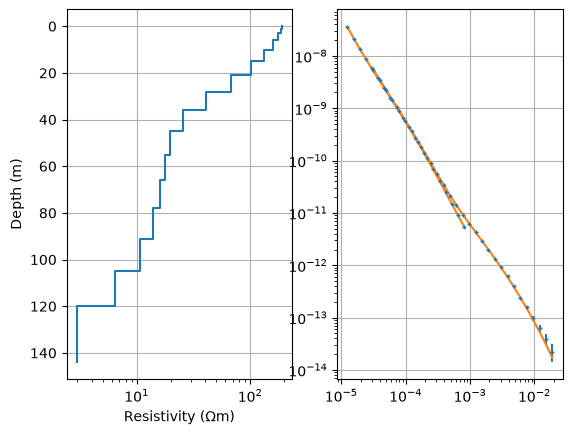

In [6]:
thk = range(1, 16)
fix.createForwardOperator(thk=thk)
fix.invertSounding(index=3)

The resistivity shows the expected behavior, and most importantly, it can fit both the low and the high moment with the same model by incorporating the transmitter waveform.

### Profiler data

We load the profiler data into a new TEM instance.

In [7]:
pro = TEM("profiler.xyz")
print(pro)

TEM profile with 5 soundings
25 times (5.605577e-06-0.0008717436)


Here, sounding number 3 is of bad quality and therefore removed.

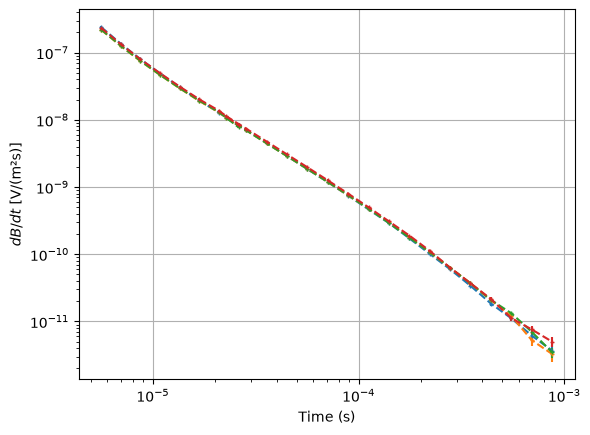

In [8]:
pro.filter(n=3)
pro.showSoundings();

The soundings are all very close to each other, at least until 0.5ms. Low and high moment are on top of each other.
They can be a bit better separated by showing the apparent resistivity, which decreases from about 100 Ohmm to 30-40 Ohmm.

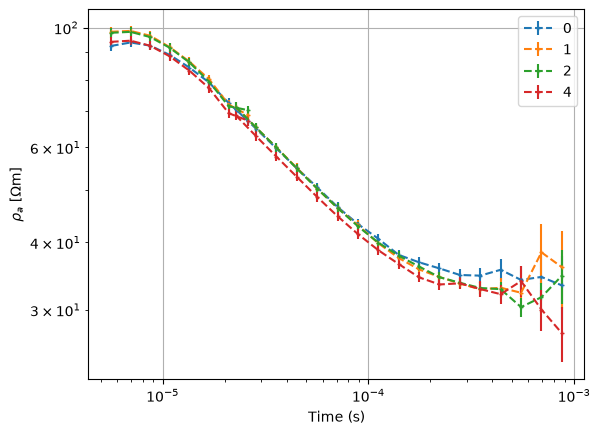

In [9]:
pro.showSoundings(rhoa=True, legend=True);

The errors increase from about 0.6ms, so we remove these data and invert sounding 2.

05/08/26 - 20:38:00 - pyGIMLi - INFO - Starting inversion.
05/08/26 - 20:38:00 - pyGIMLi - INFO - fop: <pytem.temmodelling.TEMRhoModelling object at 0x00000177698B6B60>
05/08/26 - 20:38:00 - pyGIMLi - INFO - Data transformation: Identity transform
05/08/26 - 20:38:00 - pyGIMLi - INFO - Model transformation: Logarithmic transform
05/08/26 - 20:38:00 - pyGIMLi - INFO - min/max (data): 1.3e-11/2.2e-07
05/08/26 - 20:38:00 - pyGIMLi - INFO - min/max (error): 3%/6.04%
05/08/26 - 20:38:00 - pyGIMLi - INFO - min/max (start model): 250/250


--------------------------------------------------------------------------------


05/08/26 - 20:38:24 - pyGIMLi - INFO - inv.iter 0 ... chi² =  859.58


--------------------------------------------------------------------------------
inv.iter 1 ... 

05/08/26 - 20:38:25 - pyGIMLi - INFO - chi² =  410.19 (dPhi = 51.85%) lam: 20.0


...

--------------------------------------------------------------------------------
inv.iter 8 ... 

05/08/26 - 20:41:38 - pyGIMLi - INFO - chi² =   12.82 (dPhi = 11.90%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 9 ... 

05/08/26 - 20:42:09 - pyGIMLi - INFO - chi² =   13.31 (dPhi = 1.17%) lam: 20.0


################################################################################
#                Abort criterion reached: dPhi = 1.17 (< 2.0%)                 #
################################################################################


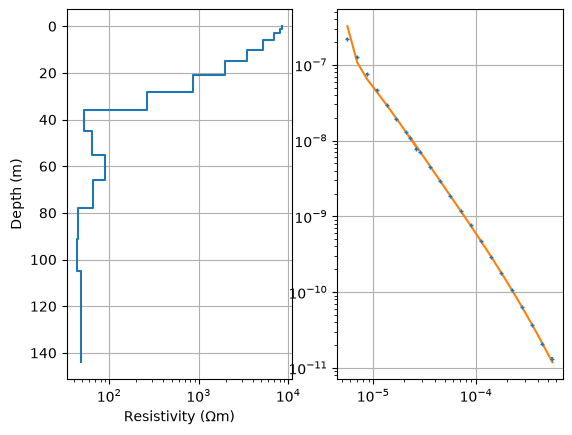

In [10]:
pro.filter(tmax=6e-4)
pro.createForwardOperator(thk=thk)
pro.invertSounding(2)

The result is similar to above but with limited depth resolution. Notably, the very early times cannot be fitted.

### Comparison

We now plot the decay curves of both measurements on top of each other. As all curves are normalized by transmitter moment and strength, they are fitting to each other.

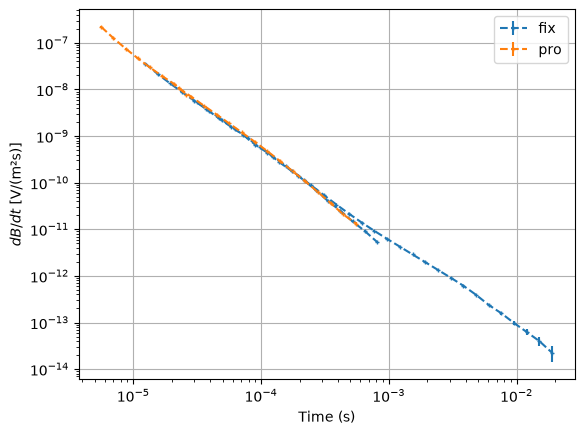

In [11]:
ax = fix.showSounding(3, label="fix")
pro.showSounding(2, ax=ax, label="pro")
ax.legend();

Interestingly, the high-moment branc (latest times) of the profiler (orange) follows the low-moment branch (early stopping) of the fixed loop. This becomes even more obvious when converting the data into apparent resistivity.

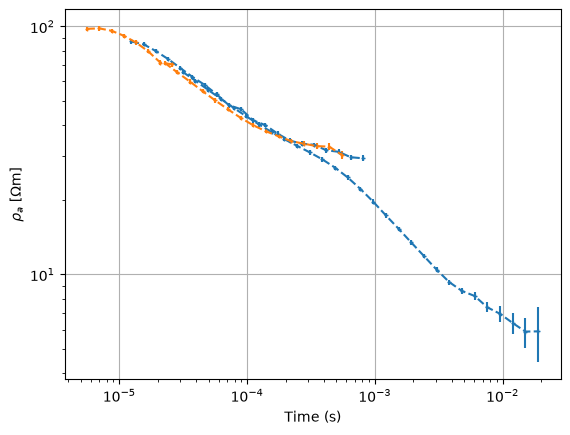

In [12]:
ax = fix.showSounding(3, rhoa=True)
pro.showSounding(2, rhoa=True, ax=ax);

The stagnation of those two branches is not expected to be caused by the subsurface as there is a very good conductor at rather shallow depth. Hence, the reason must be in the measuring scheme.

### Transmitter waveforms



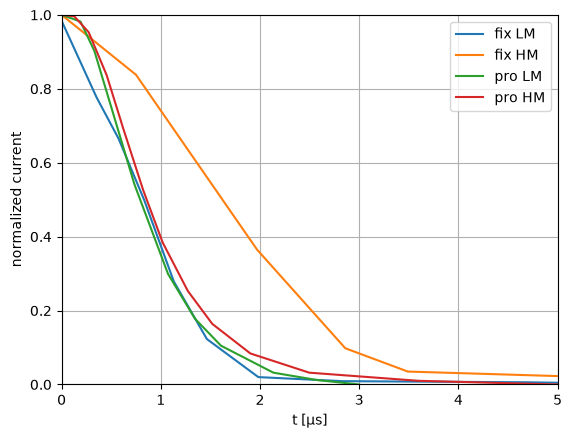

In [13]:
ax = fix.showWaveform(label="fix")
pro.showWaveform(ax=ax, label="pro")
ax.set_xlim(0, 5)
ax.set_ylim(0, 1)
ax.grid()

The shutoff times (ramp lengths) are overall rather small in the range of 3µs for the high moment of the fixed loop and 2µs for all other. The effect of the ramp is, however, only visible in the early times.

So we have a closer look at the shut-on.

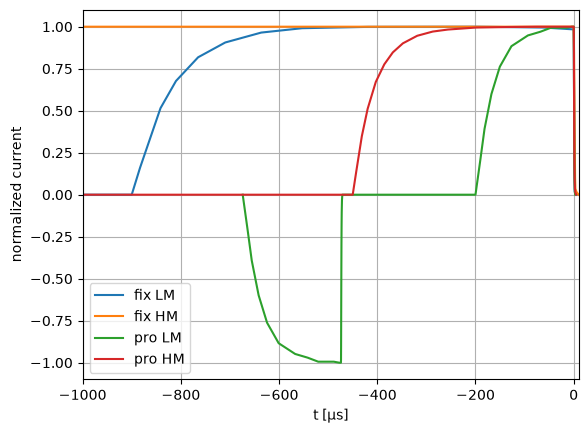

In [14]:
ax = fix.showWaveform(label="fix")
pro.showWaveform(ax=ax, label="pro")
ax.set_xlim(-1000, 10)
ax.grid()

Whereas the fixed-loop high moment has an on-time of about 2ms (not shown), its low moment has a comparable on-time to the high-moment of the profiler. The derivative of the shut-on produces an oppositely directed current system that is able to lower the signals for measuring times longer than the ramp time and therefore increases apparent resistivity. 